In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

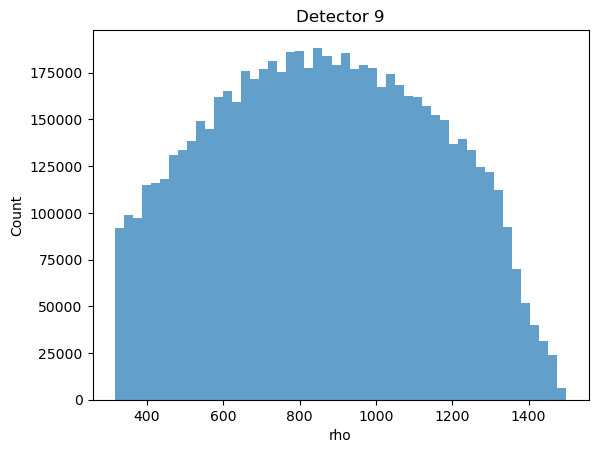

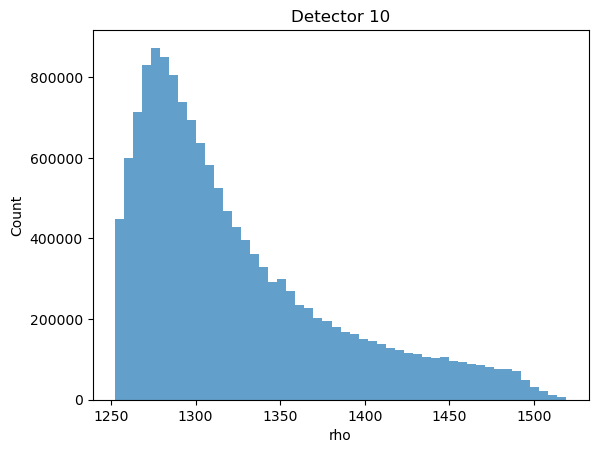

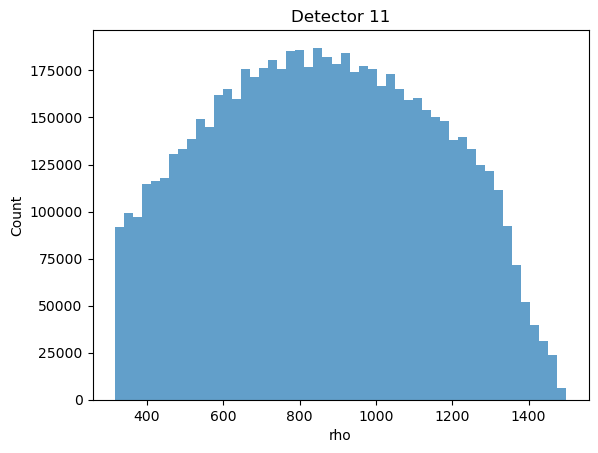

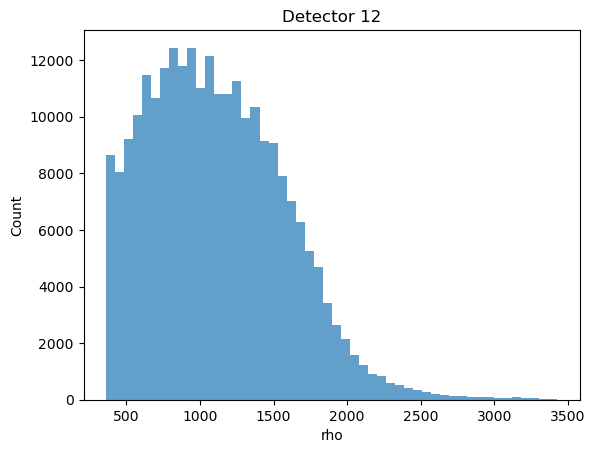

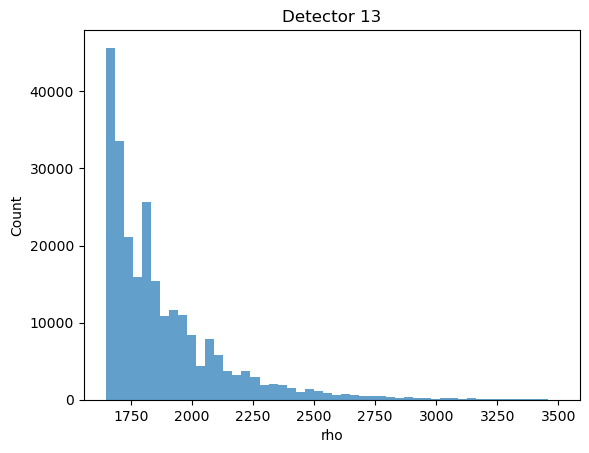

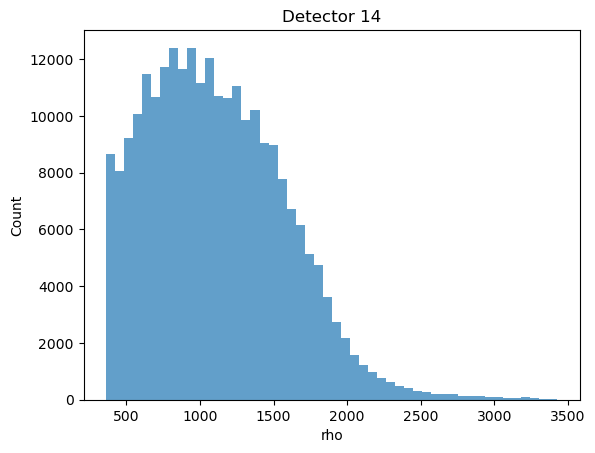

In [13]:
import matplotlib.pyplot as plt

df = (calo_hits.lazy().select('x','y','z','detector')
 .explode('x','y','z', 'detector')
 .unique()
 .with_columns((pl.col('x')**2 + pl.col('y')**2).sqrt().alias('rho'))
 .select(['rho', 'detector','z'])
 .collect()
)

detectors = df['detector'].unique().sort()

for detector in detectors:
    plt.figure()
    data = df.filter(pl.col('detector') == detector)['rho']
    plt.hist(data, bins=50, alpha=0.7)
    plt.title(f'Detector {detector}')
    plt.xlabel('rho')
    plt.ylabel('Count')
    plt.show()

In [23]:
import torch
v = torch.__version__.split('+')[0]
c = torch.version.cuda.replace('.', '')
! pip install torch_scatter -f https://data.pyg.org/whl/torch-{v}+cu{c}.html

Defaulting to user installation because normal site-packages is not writeable
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 11.6 MB/s eta 0:00:00m eta 0:00:016m0:00:010m


In [7]:
from primary.clue import run_clue_hybrid
import torch
from primary.calibration import CALIBRATION

calo = calo_hits.filter(pl.col('event_id') == 1)
energy = (
    calo.lazy().select(pl.col('total_energy'), pl.col('detector'))
    .explode('total_energy', 'detector')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('total_energy'))
    .select('total_energy')
).collect().to_numpy().reshape(-1)
# rescale energy using calibration
calo_points = torch.tensor(np.vstack([calo['x'].explode().to_numpy(), calo['y'].explode().to_numpy(), calo['z'].explode().to_numpy()]).T, dtype=torch.float32)
calo_features = torch.tensor(energy, dtype=torch.float32)
dm=20.0
rho, delta, seeds,cluster_labels = run_clue_hybrid(
    calo_points, 
    calo_features, 
    dc=15,      # Local density radius
    rhoc=0.01,   # Density cutoff (tuning required)
    dm=dm,   # Search radius for higher density neighbors
    max_num_neighbors=600
)
seed_coords = calo_points.cpu().numpy()[seeds.cpu().numpy()]



[GPU] Graph Build:    1.6643s | Edges: 14685952
[GPU] Rho Calc:       0.0022s
[GPU] Delta Calc:     0.0043s
[Trans] GPU -> CPU:   0.0014s
[CPU] Pointer Jump:   0.0213s (Converged in 7 steps)
-------------------------------------------
Total Time:           1.6936s
Found 84025 clusters.


In [12]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------

# Define System Groups based on your CALIBRATION dataframe
ecal_ids = [9, 10, 11]  # Ecal Endcap Neg, Barrel, Endcap Pos
hcal_ids = [12, 13, 14] # Hcal Endcap Neg, Barrel, Endcap Pos

# Hyper-parameters per system
# NOTE: rhoc is the most sensitive parameter. 
#       If you get too many clusters, INCREASE rhoc.
#       If you lose signal, DECREASE rhoc.

params_ecal = {
    'dc': 15.0,         # ~3x cell size (5.1mm). Captures EM core.
    'dm': 25.0,         # Search radius for higher density
    'rhoc': 0.01,       # Density threshold. ECAL cells are small, so sum is smaller.
    'max_neighbors': 200
}

params_hcal = {
    'dc': 50.0,         # MUST be > 43mm (diagonal of 30mm cell) or neighbors disconnect
    'dm': 80.0,         # Broader search for hadronic showers
    'rhoc': 0.05,        # Higher threshold. HCAL cells integrate more pileup noise.
    'max_neighbors': 200
}

# --------------------------------------------------------------------------------
# 2. HELPER FUNCTION
# --------------------------------------------------------------------------------
def run_clue_subset(full_points, full_energy, subset_mask, params, id_offset):
    """
    Runs CLUE on a subset of the data defined by the mask.
    Returns:
        - subset_ids: Global indices of the subset
        - cluster_labels: Labels for these points (offset by id_offset)
        - num_clusters: Count of new clusters found
    """
    # 1. Filter Data
    subset_idx = torch.where(subset_mask)[0]
    
    if len(subset_idx) == 0:
        return subset_idx, np.array([]), 0

    points_sub = full_points[subset_idx]
    energy_sub = full_energy[subset_idx]

    # 2. Run CLUE (Your existing function)
    _, _, is_seed, local_labels = run_clue_hybrid(
        points_sub, 
        energy_sub, 
        dc=params['dc'], 
        rhoc=params['rhoc'], 
        dm=params['dm'], 
        max_num_neighbors=params['max_neighbors']
    )

    # 3. Apply Offset to valid clusters (keep noise as -1)
    # local_labels is numpy array from your function
    final_labels = np.where(local_labels != -1, local_labels + id_offset, -1)
    
    num_new_clusters = np.sum(is_seed.cpu().numpy())
    
    return subset_idx.cpu().numpy(), final_labels, num_new_clusters

# --------------------------------------------------------------------------------
# 3. EXECUTION
# --------------------------------------------------------------------------------

# Convert detector column to tensor for fast masking
detector_ids = torch.tensor(
    calo.select('detector').explode('detector').to_series().to_numpy(), 
    device=calo_points.device
)

# Initialize Output Array (-1 = Noise)
global_cluster_ids = np.full(len(calo_points), -1, dtype=np.int32)
current_cluster_count = 0

# --- A. Run ECAL ---
print(f"Processing ECAL (IDs {ecal_ids})...")
mask_ecal = torch.isin(detector_ids, torch.tensor(ecal_ids, device=calo_points.device))
idx_ecal, lbl_ecal, n_ecal = run_clue_subset(
    calo_points, calo_features, mask_ecal, params_ecal, current_cluster_count
)
global_cluster_ids[idx_ecal] = lbl_ecal
current_cluster_count += n_ecal
print(f"  -> Found {n_ecal} clusters in ECAL")

# --- B. Run HCAL ---
print(f"Processing HCAL (IDs {hcal_ids})...")
mask_hcal = torch.isin(detector_ids, torch.tensor(hcal_ids, device=calo_points.device))
idx_hcal, lbl_hcal, n_hcal = run_clue_subset(
    calo_points, calo_features, mask_hcal, params_hcal, current_cluster_count
)
global_cluster_ids[idx_hcal] = lbl_hcal
current_cluster_count += n_hcal
print(f"  -> Found {n_hcal} clusters in HCAL")

print(f"Total Clusters: {current_cluster_count}")

# --------------------------------------------------------------------------------
# 4. ASSIGNMENT & CENTERS (Standard Logic)
# --------------------------------------------------------------------------------
# Add IDs to DataFrame
# Compute cluster center coordinates per hit
cluster_cx_list = np.full(len(calo_points), 0.0, dtype=float)
cluster_cy_list = np.full(len(calo_points), 0.0, dtype=float)
cluster_cz_list = np.full(len(calo_points), 0.0, dtype=float)

for i in range(len(global_cluster_ids)):
    if global_cluster_ids[i] != -1:
        cluster_cx_list[i] = seed_coords[global_cluster_ids[i], 0]
        cluster_cy_list[i] = seed_coords[global_cluster_ids[i], 1]
        cluster_cz_list[i] = seed_coords[global_cluster_ids[i], 2]
    else:
        # Fallback for noise: use the hit's own coordinates
        cluster_cx_list[i] = 0
        cluster_cy_list[i] = 0
        cluster_cz_list[i] = 0

# Add as list columns to the DataFrame
calo = calo.with_columns([
    pl.Series(name='cluster_cx', values=[cluster_cx_list.tolist()]),
    pl.Series(name='cluster_cy', values=[cluster_cy_list.tolist()]),
    pl.Series(name='cluster_cz', values=[cluster_cz_list.tolist()]),
    pl.Series(name='cluster_id', values=[global_cluster_ids.tolist()])
])



Processing ECAL (IDs [9, 10, 11])...
[GPU] Graph Build:    1.4416s | Edges: 24157265
[GPU] Rho Calc:       0.0025s
[GPU] Delta Calc:     0.0068s
[Trans] GPU -> CPU:   0.0013s
[CPU] Pointer Jump:   0.0215s (Converged in 7 steps)
-------------------------------------------
Total Time:           1.4737s
Found 30637 clusters.
  -> Found 30637 clusters in ECAL
Processing HCAL (IDs [12, 13, 14])...
[GPU] Graph Build:    0.0121s | Edges: 855334
[GPU] Rho Calc:       0.0003s
[GPU] Delta Calc:     0.0007s
[Trans] GPU -> CPU:   0.0002s
[CPU] Pointer Jump:   0.0010s (Converged in 6 steps)
-------------------------------------------
Total Time:           0.0145s
Found 3497 clusters.
  -> Found 3497 clusters in HCAL
Total Clusters: 34134


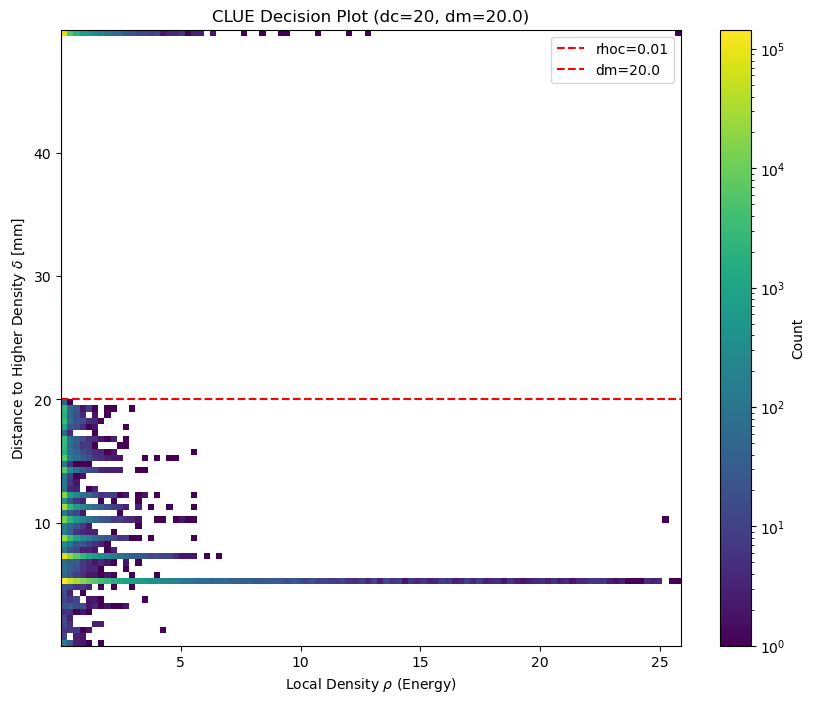

In [59]:
# ~~~ Helper to reconstruct truth mask ~~~
# (This assumes the ordering of calo_points matches the exploded DataFrame)
import matplotlib.pyplot as plt
import matplotlib.colors as colors
rhoc=0.01
dc=20
signal_df = (
    calo.lazy()
    .select(pl.col('contrib_particle_ids'), pl.col('event_id'))
    .explode('contrib_particle_ids')
    .explode('contrib_particle_ids')
    .rename({'contrib_particle_ids': 'particle_id'})
    .join((particles.lazy().select('event_id', 'particle_id', 'vertex_primary')
           .explode('particle_id','vertex_primary')),
          left_on=['event_id', 'particle_id'], 
          right_on=['event_id', 'particle_id'], how='left')
    .with_columns(pl.col('vertex_primary').fill_null(0))
    .group_by('event_id', 'particle_id') # You might need an index column
    .agg(pl.col('vertex_primary').max()) # If any contributor is primary, mark hit as primary
).collect()
# NOTE: For simplicity, if you don't have the mask ready, just plot all points first.

# 2. Plot Delta vs Rho
rho_np = rho.cpu().numpy()
delta_np = delta.cpu().numpy()

# Handle infinity in delta (global maximums) for plotting
max_delta_val = np.nanmax(delta_np[delta_np != np.inf])
delta_plot = np.minimum(delta_np, max_delta_val * 2.5)

plt.figure(figsize=(10, 8))
plt.hist2d(rho_np, delta_plot, bins=[100, 100], norm=colors.LogNorm(), cmap='viridis')
plt.colorbar(label='Count')
plt.xlabel(r'Local Density $\rho$ (Energy)')
plt.ylabel(r'Distance to Higher Density $\delta$ [mm]')
plt.title(f'CLUE Decision Plot (dc={dc}, dm={dm})')

# Overlay the cut thresholds
plt.axvline(x=rhoc, color='red', linestyle='--', label=f'rhoc={rhoc}')
plt.axhline(y=dm, color='red', linestyle='--', label=f'dm={dm}')
plt.legend()
plt.show()

In [64]:
calo_points = torch.tensor(np.vstack([calo['x'].explode().to_numpy(), calo['y'].explode().to_numpy(), calo['z'].explode().to_numpy()]).T, dtype=torch.float32)
calo_features = torch.tensor(energy, dtype=torch.float32)
calo_features.shape, calo_points.shape

(torch.Size([622618]), torch.Size([622618, 3]))

In [61]:
# Move to CPU for plotting
rho_np = rho.cpu().numpy()
delta_np = delta.cpu().numpy()

from scipy.spatial import cKDTree
# Get coordinates of seed points (seeds is a boolean mask from run_clue_pytorch)
seed_coords = calo_points.cpu().numpy()[seeds.cpu().numpy()]
tree = cKDTree(seed_coords)

# Vectorized query: find nearest seed for all points in 3D space
dist, idx = tree.query(calo_points.cpu().numpy(), distance_upper_bound=dm)

# Assign labels: -1 for noise, index of nearest seed for others
cluster_labels = np.full(len(calo_points), -1, dtype=int)
mask = dist <= dm
cluster_labels[mask] = idx[mask]

In [65]:
# Compute cluster center coordinates per hit
cluster_cx_list = np.full(len(calo_points), 0.0, dtype=float)
cluster_cy_list = np.full(len(calo_points), 0.0, dtype=float)
cluster_cz_list = np.full(len(calo_points), 0.0, dtype=float)

for i in range(len(cluster_labels)):
    if cluster_labels[i] != -1:
        cluster_cx_list[i] = seed_coords[cluster_labels[i], 0]
        cluster_cy_list[i] = seed_coords[cluster_labels[i], 1]
        cluster_cz_list[i] = seed_coords[cluster_labels[i], 2]
    else:
        # Fallback for noise: use the hit's own coordinates
        cluster_cx_list[i] = 0
        cluster_cy_list[i] = 0
        cluster_cz_list[i] = 0

# Add as list columns to the DataFrame
calo = calo.with_columns([
    pl.Series(name='cluster_cx', values=[cluster_cx_list.tolist()]),
    pl.Series(name='cluster_cy', values=[cluster_cy_list.tolist()]),
    pl.Series(name='cluster_cz', values=[cluster_cz_list.tolist()]),
    pl.Series(name='cluster_id', values=[cluster_labels.tolist()])
])
# Add seeds coordinates to calo dataframe
cluster_cx = seed_coords[:, 0].reshape(-1,1)
cluster_cy = seed_coords[:, 1].reshape(-1,1)
cluster_cz = seed_coords[:, 2].reshape(-1,1)


In [66]:
# Calculate noise accumulated energy and signal clusters accumulated energy

from primary.calibration import CALIBRATION

# Explode calo to get per-hit data
exploded = (
    calo.lazy()
    .select('total_energy', 'detector', 'cluster_id')
    .explode('total_energy', 'detector', 'cluster_id')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('calibrated_energy'))
)

# Group by cluster_id and sum calibrated energies
energy_per_cluster = (
    exploded
    .group_by('cluster_id')
    .agg(pl.col('calibrated_energy').sum().alias('total_energy'))
    .collect()
)

# Noise accumulated energy (cluster_id == -1)
noise_energy = energy_per_cluster.filter(pl.col('cluster_id') == -1)['total_energy'].sum()

# Signal clusters accumulated energy (cluster_id != -1)
signal_clusters_energy = energy_per_cluster.filter(pl.col('cluster_id') != -1)

# Sum all signal clusters together
total_signal_energy = signal_clusters_energy['total_energy'].sum()

print(f"Noise accumulated energy: {noise_energy}")
print(f"Total signal clusters accumulated energy: {total_signal_energy}")

Noise accumulated energy: 1250.750605650949
Total signal clusters accumulated energy: 16398.9074072866


In [99]:
(calo.lazy()
 .select('cluster_id')
 .explode('cluster_id')
    .group_by('cluster_id')
    .count()
    .sort('count', descending=True)
    .head(50)
 ).collect()

/tmp/ipykernel_3672385/1494291227.py:5: DeprecationWarning:

`count` was renamed; use `len` instead



cluster_id,count
i64,u32
-1,111360
15,28319
17,27787
8,26535
18,24100
…,…
156,1514
162,1504
196,1413


In [67]:
(calo.lazy().select('contrib_particle_ids', 'contrib_energies', 'event_id', 'cluster_id', 'detector')
 .explode('contrib_particle_ids', 'contrib_energies', 'cluster_id', 'detector')
 .explode('contrib_particle_ids', 'contrib_energies')
 .rename({'contrib_particle_ids':'particle_id', 'contrib_energies':'energy_contribution'})
 # Calibrate energy contributions
.join(CALIBRATION.lazy(), on='detector')
.with_columns((pl.col('energy_contribution') * pl.col('calib_factor')).alias('energy_contribution'))
 .join(
     particles.lazy()
     .filter(pl.col('event_id')==1)
     .select('event_id', 'particle_id','vertex_primary')
     .explode('particle_id','vertex_primary'), on=['event_id','particle_id'], how='inner'

 )
 #.filter(pl.col('vertex_primary')==1)
 .with_columns(pl.when(pl.col('vertex_primary') == 1).then(1).otherwise(0).alias('hard_scatter'))
 # two classes: cluster_id == -1 (noise), cluster_id != -1 (signal)
 .with_columns(pl.when(pl.col('cluster_id') == -1).then(0).otherwise(1).alias('is_signal'))
 .group_by('is_signal', 'event_id', 'hard_scatter')
 .agg(pl.col('energy_contribution').sum().alias('primary_energy_contribution'))
 ).collect()

is_signal,event_id,hard_scatter,primary_energy_contribution
i32,u32,i32,f64
0,1,1,65.232418
1,1,1,1075.214637
0,1,0,1185.518188
1,1,0,15323.69277


In [68]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 1), event_idx=1)


FigureWidget({
    'data': [{'customdata': array([[31071, 0.14617327842643135, 1.0,
                                    '<b>e+</b> (PDG:-11) ID:173993: <b>0.1107 GeV</b><br><b>e+</b> (PDG:-11) ID:173991: <b>0.018 GeV</b><br><b>e-</b> (PDG:11) ID:173992: <b>0.0151 GeV</b><br><b>e-</b> (PDG:11) ID:173990: <b>0.0024 GeV</b>'],
                                   [6041, 0.08454119693487883, 1.0,
                                    '<b>π+</b> (PDG:211) ID:170531: <b>0.0845 GeV</b>'],
                                   [30553, 0.1564233595971018, 0.523935526234681,
                                    '<b>n</b> (PDG:2112) ID:31964: <b>0.07 GeV</b><br><b>e+</b> (PDG:-11) ID:170968: <b>0.0347 GeV</b><br><b>π-</b> (PDG:-211) ID:171205: <b>0.0249 GeV</b><br><b>π+</b> (PDG:211) ID:170962: <b>0.0196 GeV</b><br><b>π-</b> (PDG:-211) ID:105577: <b>0.0044 GeV</b>'],
                                   ...,
                                   [3927, 1.8511900950223208, 0.9350489866191253,
                 

In [48]:
calo

event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times,seeds_coordinates,cluster_cx,cluster_cy,cluster_cz,cluster_id
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]],list[list[f64]],list[f64],list[f64],list[f64],list[i64]
1,"[11, 11, … 10]","[0.000176, 0.000072, … 0.000057]","[-81.599998, -306.947235, … 288.261261]","[979.78894, -343.009705, … 1268.982788]","[3399.350098, 3293.300049, … 2315.399902]","[[63413], [37771], … [144414]]","[[0.000176], [0.000072], … [0.000057]]","[[13.390422], [11.420349], … [9.125679]]","[[452.489105, -30.0, 4004.5], [-213.892105, -298.744904, 5432.5], … [-1018.269104, 902.869324, 1086.300049]]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[-1, -1, … -1]"


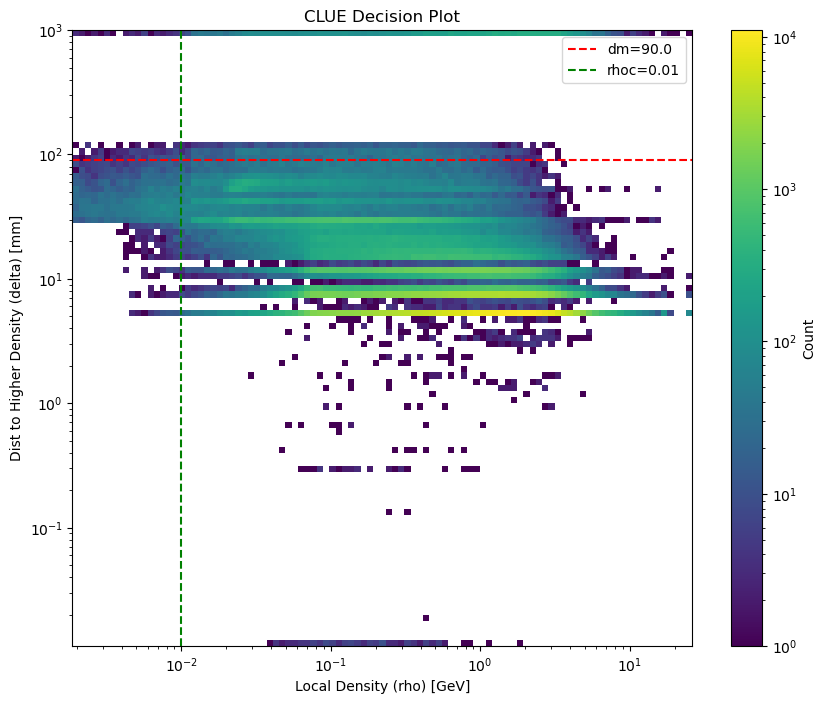

In [25]:
# Visualise Decision Plot (2D Histogram)
plt.figure(figsize=(10, 8))

# Handle infinities in delta for plotting by replacing with a large value
delta_np_plot = np.where(np.isfinite(delta_np), delta_np, 1e3)

# Define bins
x_min = max(rho_np.min(), 1e-5)
x_max = rho_np.max()
y_min = max(delta_np_plot.min(), 1e-2)
y_max = 1e3  # Extend to include high delta values

xbins = np.logspace(np.log10(x_min), np.log10(x_max), 100)
ybins = np.logspace(np.log10(y_min), np.log10(y_max), 100)

plt.hist2d(rho_np, delta_np_plot, bins=[xbins, ybins], norm=plt.matplotlib.colors.LogNorm(), cmap='viridis')
plt.colorbar(label='Count')
plt.xlabel("Local Density (rho) [GeV]")
plt.ylabel("Dist to Higher Density (delta) [mm]")
plt.title("CLUE Decision Plot")
plt.xscale('log')
plt.yscale('log')

# Draw your proposed cuts
dm_cut = 90.0
rhoc_cut = 0.01  # Example value, adjust based on the density of noise blob (bottom left)
plt.axhline(y=dm_cut, color='r', linestyle='--', label=f'dm={dm_cut}')
plt.axvline(x=rhoc_cut, color='g', linestyle='--', label=f'rhoc={rhoc_cut}')
plt.legend()
plt.show()

In [5]:
from primary.clue import run_clue_pytorch
from primary.calibration import CALIBRATION

calo = calo_hits.filter(pl.col('event_id') == 1)
energy = (
    calo.lazy().select(pl.col('total_energy'), pl.col('detector'))
    .explode('total_energy', 'detector')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('total_energy'))
    .select('total_energy')
).collect().to_numpy().reshape(-1)

In [6]:
energy.shape

(622618,)

In [38]:
delta_np

array([inf, inf, inf, ..., inf, inf, inf], shape=(622618,), dtype=float32)

In [34]:
calo_points.shape, calo_features.shape

(torch.Size([622618, 3]), torch.Size([622618, 1]))

In [26]:
delta

tensor([0.4630, 0.5809, 2.3646,  ..., 0.0000, 0.0000, 0.0000], device='cuda:0')

In [20]:
v = torch.__version__.split('+')[0]
c = torch.version.cuda# filepath: /storage/agrp/barakma/PileupODD/pileup_analysis.ipynb

c,v

('12.6', '2.6.0')

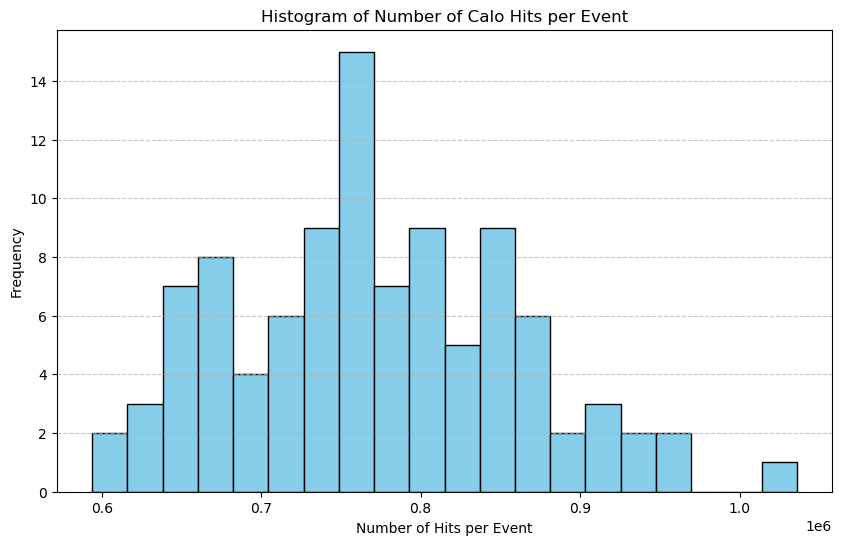

In [10]:
import matplotlib.pyplot as plt

# Compute the number of hits per event
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles_copy = particles.clone()

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 9397289 depositors.


In [65]:
particles = set_target_particles_maskv3(particles, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)

Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [24]:
import matplotlib.pyplot as plt
import polars as pl

# Calculate number of particles per vertex_primary
particles_per_vertex = (
    particles.lazy()
    .select('vertex_primary', 'event_id')
    .explode('vertex_primary')
    .group_by('vertex_primary', 'event_id')
    .len()
    .collect()
)

# Compute averages for categories
avg_particles_gt1 = particles_per_vertex.filter(pl.col('vertex_primary') > 1)['len'].mean()
avg_particles_eq1 = particles_per_vertex.filter(pl.col('vertex_primary') == 1)['len'].mean()

# Create a DataFrame for display
averages = pl.DataFrame({
    'Category': ['vertex_primary > 1', 'vertex_primary == 1'],
    'Average Particles': [avg_particles_gt1, avg_particles_eq1]
})

print(averages)

shape: (2, 2)
┌─────────────────────┬───────────────────┐
│ Category            ┆ Average Particles │
│ ---                 ┆ ---               │
│ str                 ┆ f64               │
╞═════════════════════╪═══════════════════╡
│ vertex_primary > 1  ┆ 854.927233        │
│ vertex_primary == 1 ┆ 5231.93           │
└─────────────────────┴───────────────────┘


In [33]:
(particles.lazy()
    .select('vertex_primary', 'event_id', 'is_parent_missing')
    .explode('vertex_primary', 'is_parent_missing')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()

vertex_primary,event_id,is_parent_missing
u16,u32,bool
1,26,true
1,26,true
1,26,true
1,26,true
1,26,true
…,…,…
211,90,true
211,90,true
211,90,true


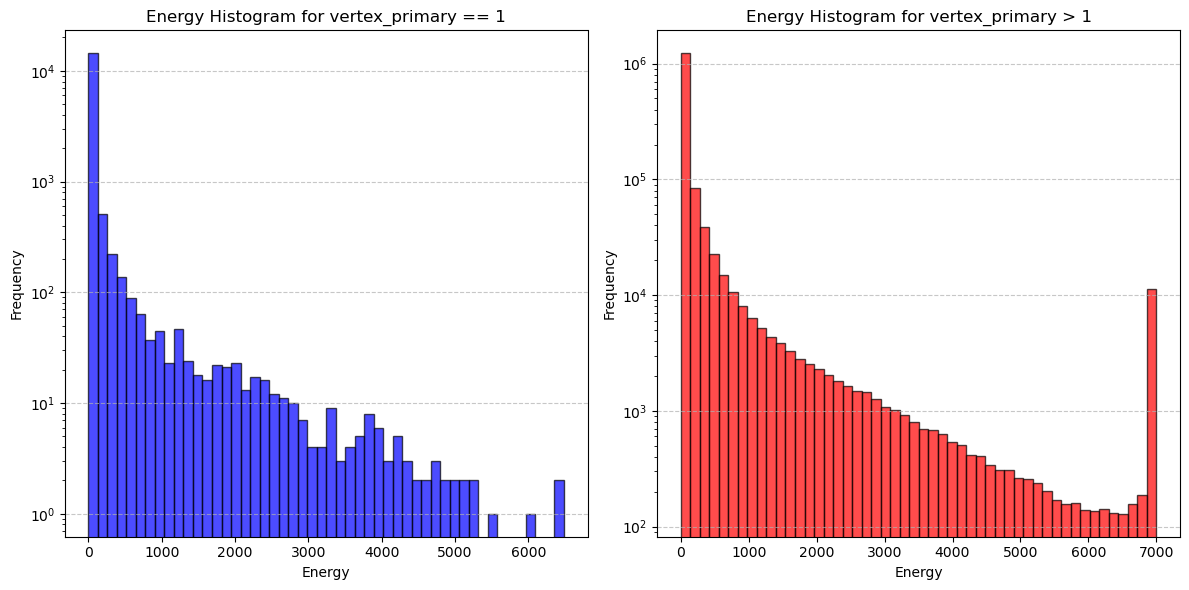

In [36]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (particles.lazy()
    .select('vertex_primary',  'is_parent_missing', 'energy')
    .explode('vertex_primary', 'is_parent_missing', 'energy')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()
# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['energy']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['energy']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary == 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary > 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

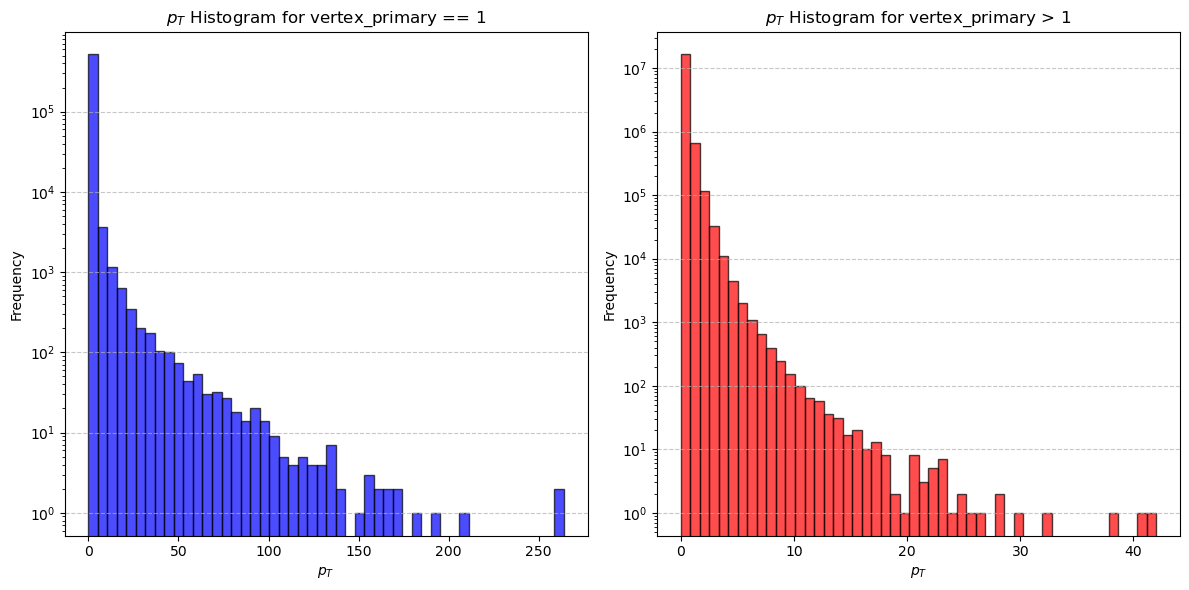

In [30]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (
    particles.lazy()
    .select('vertex_primary', 'pt')
    .explode('vertex_primary', 'pt')
    .collect()
)

# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['pt']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['pt']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary == 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary > 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

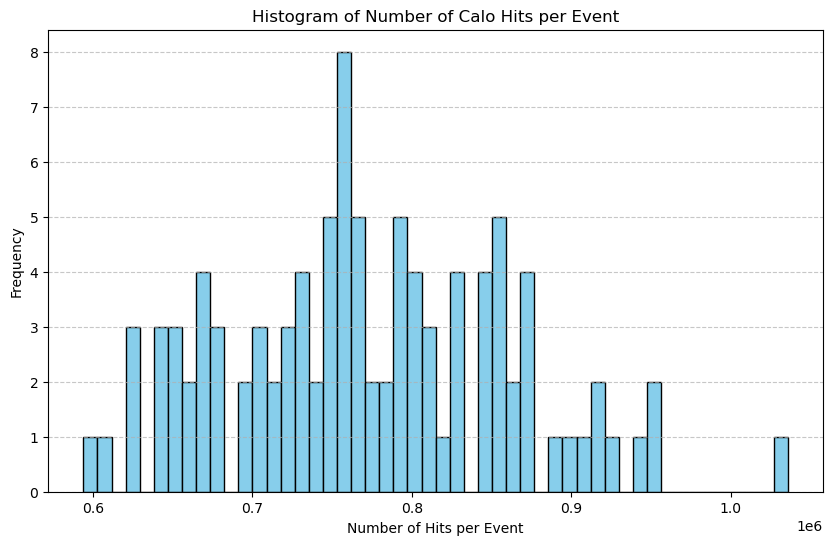

In [6]:
import matplotlib.pyplot as plt

# Since the schema uses list columns for each event, the number of hits is the length of these lists.
# We group by event_id and sum the lengths in case an event is split across multiple rows.
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from primary.calibration import CALIBRATION
()

In [12]:
# bad config
from primary.interactive_plot import target_vs_truth_particles
target_vs_truth_particles(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 11 iterations.
Step 4: Final validation...


    'data': [{'customdata': array([[  331.        ,  9261.1640625 ],
           …

In [9]:
from primary.preprocessing import add_ms_cluster_labels
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels(calo, bandwidth=120.0)

--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1 events. Time: 0.02s
Workload optimized: 1 events merged into 1 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 179.65s


In [9]:
from primary.preprocessing import add_ms_cluster_labels_gpu
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels_gpu(calo, bandwidth=120.0)

--- Starting FAST GPU Clustering (Float32, MeanShift, bw=120.0) ---
Data prepared: 1 events. GPU Load Time: 0.04s


Processing Events:   0%|                                                                                                                 | 0/1 [01:37<?, ?it/s]


AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [8]:
import torch

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

GPU: NVIDIA RTX A5000


In [12]:
particles.select('vertex_primary')

vertex_primary
list[u16]
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
…
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"


In [49]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)


No clusters found for event 0.


event_id,ht_target,ht_truth
u32,f32,f32
10,3771.317871,3915.379639
19,2959.985596,3048.139404
35,3465.338867,3584.286865
69,3455.357666,3595.883545
12,2864.208252,2972.331543
…,…,…
32,3615.420898,3717.498047
84,2428.414307,2522.760742
44,3639.218018,3829.91626


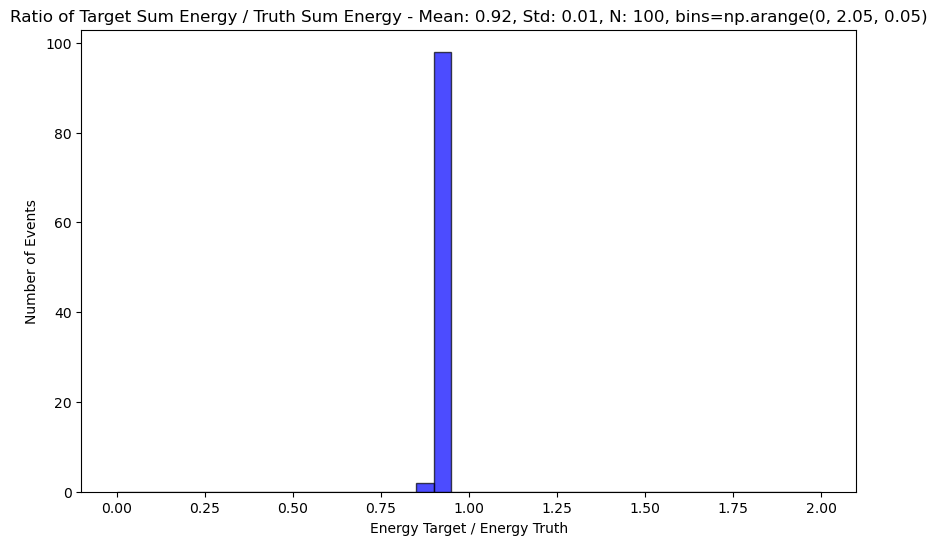

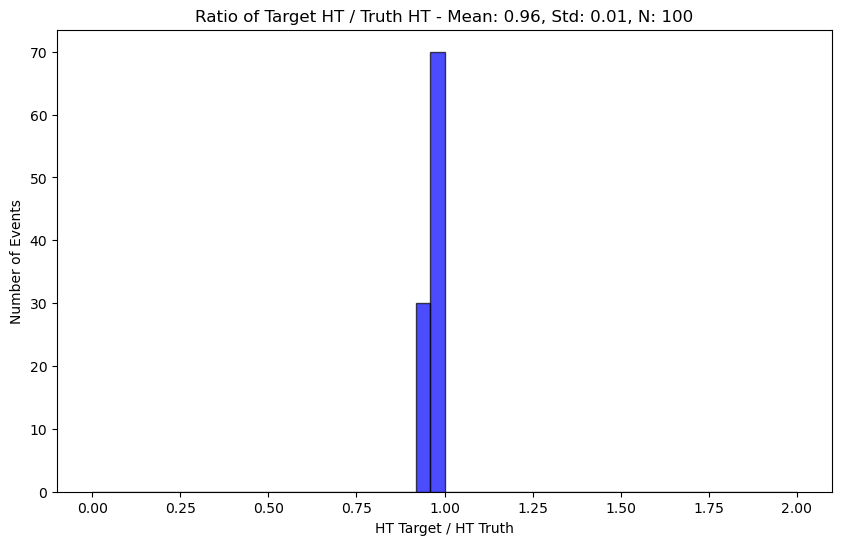

In [13]:
from primary.plot import histogram_ht_ratio,hist2d_ht_truth_vs_target, histogram_energy_ratio
histogram_energy_ratio(particles)
histogram_ht_ratio(particles)

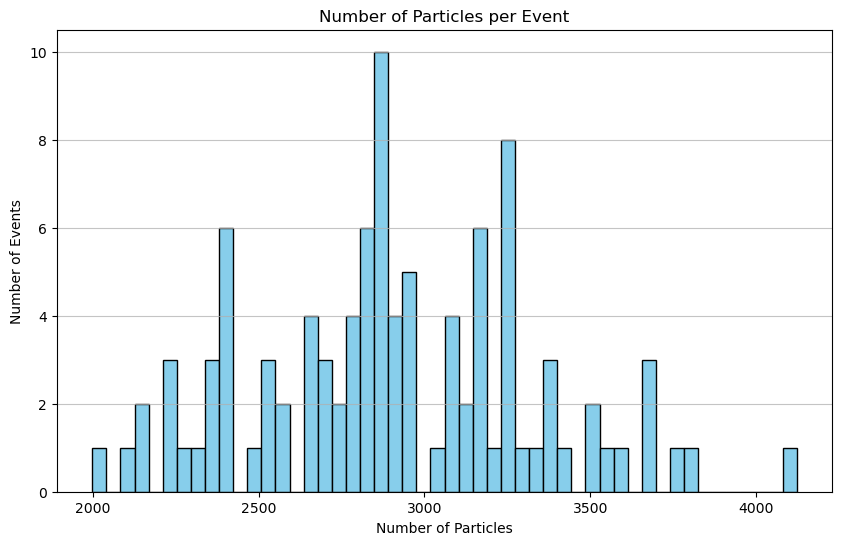

In [15]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle')
    .explode('particle_id', 'is_target_particle')
    .filter('is_target_particle')
    .group_by('event_id')
    .agg(pl.col('particle_id').count().alias('num_particles'))
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(n_particles['num_particles'], bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()